# Neural Network - A Simple Perceptron
## Assignment Code: DS-AG-019

---

# Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

**Answer:**

Deep Learning is a subset of machine learning that uses artificial neural networks with multiple layers to learn patterns from large amounts of data. These neural networks are inspired by the structure and functioning of the human brain.

Deep learning evolved from early neural network research in the 1950s with the perceptron model. However, due to limited computing power and data availability, progress was slow. With the rise of big data, powerful GPUs, and improved algorithms in the 2010s, deep learning gained significant popularity and became widely used in areas such as computer vision, natural language processing, and speech recognition.

Traditional machine learning relies heavily on manual feature engineering, where experts design features from raw data. Deep learning automatically learns features directly from raw data through multiple neural network layers. This makes deep learning especially effective for complex tasks such as image recognition and language understanding.

---

# Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

**Answer:**

A Perceptron is the simplest type of artificial neural network and serves as the basic building block of more complex neural networks. It is a supervised learning algorithm used for binary classification.

The architecture of a perceptron consists of:

- Input layer (features)
- Weights assigned to each input
- Bias term
- Activation function
- Output layer

The perceptron computes a weighted sum of inputs and passes the result through an activation function to generate the final output.

Mathematically:

output = activation(weighted sum of inputs + bias)

If the weighted sum exceeds a threshold, the perceptron outputs one class; otherwise it outputs another.

**Limitations:**

- Can only solve linearly separable problems
- Cannot learn complex patterns
- Cannot solve problems like XOR
- Limited representation power

Because of these limitations, multilayer neural networks were developed.

---

# Question 3: Describe the purpose of activation functions in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

**Answer:**

Activation functions introduce non-linearity into neural networks. Without activation functions, neural networks would behave like simple linear regression models and would not be able to learn complex relationships in data.

Activation functions determine whether a neuron should be activated or not based on its input.

**Sigmoid Function**
- Output range: 0 to 1
- Often used for binary classification
- Can suffer from vanishing gradient problems

**Tanh Function**
- Output range: -1 to 1
- Zero-centered output
- Still suffers from vanishing gradient issues

**ReLU (Rectified Linear Unit)**
- Output range: 0 to infinity
- Computationally efficient
- Helps reduce vanishing gradient problems
- Most commonly used activation function in deep learning

| Activation | Range | Advantage | Disadvantage |
|------------|------|-----------|--------------|
| Sigmoid | 0 to 1 | Good for probabilities | Vanishing gradient |
| Tanh | -1 to 1 | Zero-centered | Still vanishing gradient |
| ReLU | 0 to ∞ | Fast and efficient | Dead neuron problem |

---

# Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

**Answer:**

A **Loss Function** measures the error for a single training example. It calculates how far the predicted output is from the actual output.

A **Cost Function** is the average of the loss values across the entire training dataset. It represents the overall error of the model.

In simple terms:

Loss → error for one data point  
Cost → average loss for the entire dataset

Examples of common loss functions include:

- Mean Squared Error (MSE)
- Binary Cross Entropy
- Categorical Cross Entropy

For example, Mean Squared Error calculates the average squared difference between predicted and actual values.

Loss and cost functions help the neural network adjust its weights during training.

---

# Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

**Answer:**

Optimizers are algorithms used to update the weights of a neural network in order to minimize the loss or cost function during training.

They work by calculating gradients of the loss function and adjusting the model parameters accordingly.

**Gradient Descent**
- Basic optimization algorithm
- Updates weights using gradients
- Can be slow for large datasets

**RMSprop**
- Adapts learning rate based on recent gradients
- Faster convergence
- Works well for recurrent neural networks

**Adam (Adaptive Moment Estimation)**
- Combines advantages of RMSprop and Momentum
- Uses adaptive learning rates
- Most widely used optimizer in deep learning

| Optimizer | Speed | Stability | Usage |
|-----------|------|-----------|------|
| Gradient Descent | Slow | Moderate | Simple models |
| RMSprop | Faster | Stable | RNNs |
| Adam | Fastest | Highly stable | Deep learning models |

Adam is commonly preferred because it provides fast convergence and reliable performance.

In [1]:
# Question 6
# Implement single layer perceptron using NumPy for AND gate

import numpy as np

# AND gate dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# initialize weights and bias
weights = np.random.rand(2)
bias = np.random.rand()
lr = 0.1

def step(x):
    return 1 if x >= 0 else 0

# training
for epoch in range(10):
    for i in range(len(X)):
        linear = np.dot(X[i],weights) + bias
        pred = step(linear)
        error = y[i] - pred

        weights += lr * error * X[i]
        bias += lr * error

# testing
print("Predictions:")
for x in X:
    linear = np.dot(x,weights) + bias
    print(x,"->",step(linear))

Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


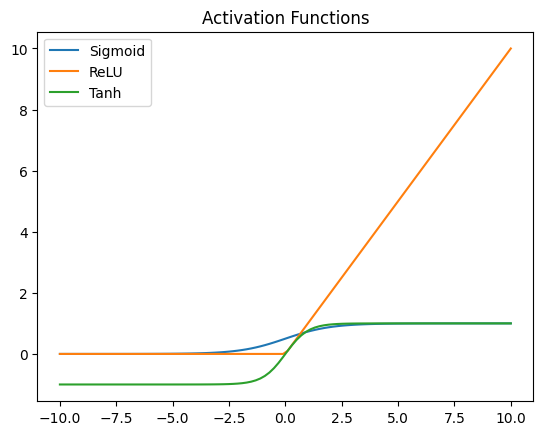

In [2]:
# Question 7
# Visualize Sigmoid, ReLU, and Tanh

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)

sigmoid = 1/(1+np.exp(-x))
relu = np.maximum(0,x)
tanh = np.tanh(x)

plt.plot(x,sigmoid,label="Sigmoid")
plt.plot(x,relu,label="ReLU")
plt.plot(x,tanh,label="Tanh")

plt.legend()
plt.title("Activation Functions")
plt.show()

In [3]:
# Question 8
# Multilayer neural network on MNIST dataset

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

(X_train,y_train),(X_test,y_test)=mnist.load_data()

X_train=X_train/255
X_test=X_test/255

model=Sequential([
Flatten(input_shape=(28,28)),
Dense(128,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=5)

loss,acc=model.evaluate(X_test,y_test)

print("Test Accuracy:",acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9277 - loss: 0.2529
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9666 - loss: 0.1095
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9776 - loss: 0.0750
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9835 - loss: 0.0553
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9868 - loss: 0.0435
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0744
Test Accuracy: 0.977400004863739


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8238 - loss: 0.5041
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8636 - loss: 0.3783
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8761 - loss: 0.3387
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8843 - loss: 0.3149
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8900 - loss: 0.2971


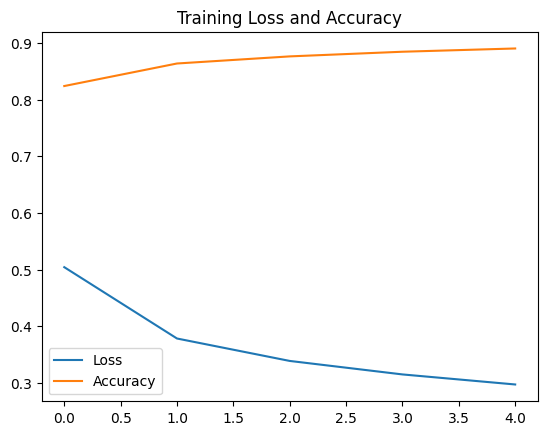

In [4]:
# Question 9
# Plot loss and accuracy curves

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential

(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

X_train=X_train/255
X_test=X_test/255

model=Sequential([
Flatten(input_shape=(28,28)),
Dense(128,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history=model.fit(X_train,y_train,epochs=5)

plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])

plt.title("Training Loss and Accuracy")
plt.legend(['Loss','Accuracy'])
plt.show()

In [5]:
# Question 10
# Example deep learning model for fraud detection

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# dummy dataset
import numpy as np

X=np.random.rand(1000,10)
y=np.random.randint(0,2,1000)

model=Sequential([
Dense(32,activation='relu',input_shape=(10,)),
Dense(16,activation='relu'),
Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X,y,epochs=5)

print("Model trained for fraud detection example")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5040 - loss: 0.6967
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5360 - loss: 0.6917
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5160 - loss: 0.6902
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5370 - loss: 0.6890
Model trained for fraud detection example
